#  Predictive Modelling
This notebook addresses Part 2 of the assessment: Building a model to predict cancelled or refunded bookings.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('cleaned_clarity_bookings.csv')

In [22]:
df.head(5)

,booking_id,booking_date,departure_date,lead_time_days,airline,origin,destination,haul_type,cabin_class,trip_type,...,booking_day,travel_month,fare_per_passenger,booking_window,loyalty_segment,is_cancelled,lead_time_bin,fare_quintile,booking_month_name,customer_type
0,CLR-00001,2025-11-24,2025-12-09,15,Air Canada,DEL,LHR,Long-Haul,Economy,Round-Trip,...,Monday,December,20538.22,Short_Term,New,0,8-30d,Q2,Nov,New Customer
1,CLR-00002,2025-06-24,2025-07-30,36,Condor,BLR,FRA,Long-Haul,First,One-Way,...,Tuesday,July,338949.12,Planned,New,1,31-90d,Q5\n(Highest),Jun,New Customer
2,CLR-00003,2025-05-29,2025-06-09,11,KLM,DEL,JFK,Long-Haul,Economy,One-Way,...,Thursday,June,51552.04,Short_Term,New,0,8-30d,Q2,May,New Customer
3,CLR-00004,2025-04-28,2025-08-12,106,American Airlines,BOM,DXB,Medium-Haul,Economy,Round-Trip,...,Monday,August,21734.13,Early_Bird,New,0,91-180d,Q3,Apr,New Customer
4,CLR-00005,2025-01-25,2025-05-16,111,Etihad Airways,DEL,CDG,Long-Haul,Premium Economy,One-Way,...,Saturday,May,81833.48,Early_Bird,Occasional,0,91-180d,Q3,Jan,Repeat Customer


In [23]:
df.describe()

,lead_time_days,pax_count,base_fare_inr,taxes_inr,total_fare_inr,ancillary_revenue_inr,prior_bookings,satisfaction_score,calculated_lead_time,expected_total_fare,booking_month,fare_per_passenger,is_cancelled
count,2000.000000,2000.00000,2000.00000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,61.278000,2.08700,52354.05989,7898.540460,1.253193e+05,3224.401410,3.790000,3.723000,61.278000,1.253193e+05,6.462500,60252.600350,0.225500
std,34.401155,1.19505,47830.89132,7920.876238,1.537680e+05,4847.870447,6.224409,1.047291,34.401155,1.537680e+05,3.468373,55255.397426,0.418016
min,1.000000,1.00000,8084.06000,768.030000,8.911110e+03,0.000000,0.000000,1.000000,1.000000,8.911110e+03,1.000000,8911.110000,0.000000
25%,31.000000,1.00000,22122.60250,3219.677500,4.235889e+04,0.000000,0.000000,3.000000,31.000000,4.235889e+04,3.000000,25177.375000,0.000000
50%,62.000000,2.00000,36681.45000,5273.425000,7.803476e+04,1400.840000,0.000000,4.000000,62.000000,7.803476e+04,6.000000,42207.295000,0.000000
75%,91.000000,3.00000,62549.99250,9306.990000,1.476526e+05,4186.942500,6.000000,4.000000,91.000000,1.476526e+05,10.000000,71069.022500,0.000000
max,120.000000,6.00000,328167.32000,67222.850000,1.729676e+06,40214.880000,20.000000,5.000000,120.000000,1.729676e+06,12.000000,395390.170000,1.000000


## 1. Feature Engineering
Deriving domain-specific features and creating the binary target variable.

In [24]:
# ==========================
# FEATURE ENGINEERING
# ==========================

# Convert date columns
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["departure_date"] = pd.to_datetime(df["departure_date"])

# 1. Target Variable: is_cancelled (1 if Cancelled or Refunded, else 0)
df["is_cancelled"] = (df["booking_status"].isin(["Cancelled", "Refunded"]).astype(int))

# 2. Fare Per Passenger
df["fare_per_passenger"] = (df["total_fare_inr"] /df["pax_count"])

# 3. Booking Month
df["booking_month"] = (df["booking_date"].dt.month)

# 4. Repeat Customer Flag
df["is_repeat_customer"] = (df["prior_bookings"] > 0).astype(int)

# 5. Route
df["route"] = (df["origin"] + "-" + df["destination"])

# 6. Fare to Average Route Fare
route_avg_fare = (df.groupby("route")["total_fare_inr"].transform("mean"))

df["fare_to_avg_route_fare"] = (df["total_fare_inr"] /route_avg_fare)

# 7. Complaint Flag
df["has_complaint"] = (df["customer_complaint"] != "No").astype(int)

# 8. Weekend Booking
df["is_weekend_booking"] = (df["booking_date"].dt.dayofweek >= 5).astype(int)

# 9. Weekend Travel
df["is_weekend_travel"] = (df["departure_date"].dt.dayofweek >= 5).astype(int)

# 10. Ancillary Revenue Ratio
df["ancillary_ratio"] = (df["ancillary_revenue_inr"] /df["total_fare_inr"])

# 11. Customer Type
df["customer_type"] = np.where(df["prior_bookings"] > 0,"Repeat","New")


In [25]:

# ==========================
# CHECK ENGINEERED FEATURES
# ==========================

engineered_features = [
    "is_cancelled",
    "fare_per_passenger",
    "booking_month",
    "is_repeat_customer",
    "route",
    "fare_to_avg_route_fare",
    "has_complaint",
    "is_weekend_booking",
    "is_weekend_travel",
    "ancillary_ratio",
    "customer_type"
]

print(f"Dataset shape after feature engineering: {df.shape}")

df[engineered_features].head()

Dataset shape after feature engineering: (2000, 43)


,is_cancelled,fare_per_passenger,booking_month,is_repeat_customer,route,fare_to_avg_route_fare,has_complaint,is_weekend_booking,is_weekend_travel,ancillary_ratio,customer_type
0,0,20538.22,11,0,DEL-LHR,0.265571,0,0,0,0.000000,New
1,1,338949.12,6,0,BLR-FRA,7.529346,0,0,0,0.009217,New
2,0,51552.04,5,0,DEL-JFK,0.295204,0,0,0,0.000000,New
3,0,21734.13,4,0,BOM-DXB,0.864546,0,0,0,0.103526,New
4,0,81833.48,1,1,DEL-CDG,0.513648,0,1,0,0.000000,Repeat


## 2. Data Preprocessing & Splitting
Selecting features and building a transformation pipeline.

### Step 1: Select Categorical Columns

In [26]:
categorical_cols = [
    "airline",
    "haul_type",
    "cabin_class",
    "trip_type",
    "fare_basis",
    "booking_channel",
    "booking_source",
    "payment_method",
    "route",
    "booking_day",
    "travel_month",
    "booking_window",
    "loyalty_segment",
    "lead_time_bin",
    "fare_quintile",
    "booking_month_name",
    "customer_type"
]

In [27]:
numerical_cols = [
    "lead_time_days",
    "pax_count",
    "base_fare_inr",
    "taxes_inr",
    "total_fare_inr",
    "ancillary_revenue_inr",
    "prior_bookings",
    "satisfaction_score",
    "booking_month",
    "fare_per_passenger",
    "is_repeat_customer",
    "fare_to_avg_route_fare",
    "has_complaint",
    "is_weekend_booking",
    "is_weekend_travel",
    "ancillary_ratio"
]

### Step 2: Apply One-Hot Encoding

In [28]:
encoder_onehot = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded_features = encoder_onehot.fit_transform(df[categorical_cols])
print(encoded_features)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]]


### Step 3: Convert to DataFrame 

In [29]:
encoded_df = pd.DataFrame(encoded_features,columns=encoder_onehot.get_feature_names_out(categorical_cols))
print(encoded_df.head())

   airline_Air France  airline_American Airlines  airline_British Airways  \
0                 0.0                        0.0                      0.0   
1                 0.0                        0.0                      0.0   
2                 0.0                        0.0                      0.0   
3                 0.0                        1.0                      0.0   
4                 0.0                        0.0                      0.0   

   airline_Condor  airline_Emirates  airline_Etihad Airways  airline_KLM  \
0             0.0               0.0                     0.0          0.0   
1             1.0               0.0                     0.0          0.0   
2             0.0               0.0                     0.0          1.0   
3             0.0               0.0                     0.0          0.0   
4             0.0               0.0                     1.0          0.0   

   airline_Lufthansa  airline_Singapore Airlines  haul_type_Medium-Haul  ...  \


In [30]:
# Target
y = df["is_cancelled"]

In [31]:
# Categorical Features
categorical_features = [
    "airline",
    "haul_type",
    "cabin_class",
    "trip_type",
    "fare_basis",
    "booking_channel",
    "booking_source",
    "payment_method",
    "route",
    "booking_day",
    "travel_month",
    "booking_window",
    "loyalty_segment",
    "lead_time_bin",
    "fare_quintile",
    "booking_month_name",
    "customer_type"
]

# Numerical Features
numerical_features = [
    "lead_time_days",
    "pax_count",
    "base_fare_inr",
    "taxes_inr",
    "total_fare_inr",
    "ancillary_revenue_inr",
    "prior_bookings",
    "satisfaction_score",
    "booking_month",
    "fare_per_passenger"
]

# Feature Matrix
X = df[categorical_features + numerical_features]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2000, 27)
y Shape: (2000,)


In [32]:
# 2. Define features and target
X = df[categorical_features + numerical_features] # independent variable / Features / X
Y=df['is_cancelled'] # dependent variable / Target/Label / y

In [33]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nCategorical Features:", len(categorical_features))
print("Numerical Features:", len(numerical_features))
print("Total Features:", len(categorical_features) + len(numerical_features))

Feature Matrix Shape: (2000, 27)
Target Shape: (2000,)

Categorical Features: 17
Numerical Features: 10
Total Features: 27


In [34]:
# 3. Train-test split (80/20 with stratification)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts(normalize=True)}\n")

Training set: (1600, 27), Test set: (400, 27)
Target distribution (train):
is_cancelled
0    0.774375
1    0.225625
Name: proportion, dtype: float64



### Feature Scaling


In [43]:
# Apply Scaling
# Define columns based on scaling strategy

# StandardScaler → Logistic Regression needs scaling
standard_cols = [
    "lead_time_days",
    "pax_count",
    "base_fare_inr",
    "taxes_inr",
    "total_fare_inr",
    "ancillary_revenue_inr",
    "prior_bookings",
    "booking_month",
    "fare_per_passenger"
]
# No strong need for MinMaxScaler RobustScaler

# Initialize scaler
scaler_standard = StandardScaler()

# Work on copies (avoid modifying original data)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Apply Standardscaler
X_train_scaled[standard_cols] = scaler_standard.fit_transform(X_train[standard_cols])
X_test_scaled[standard_cols] = scaler_standard.transform(X_test[standard_cols])

# Identify remaining columns
numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns.difference(standard_cols)
categorical_cols = X.select_dtypes(include=["object"]).columns

### Preprocessing with ColumnTransformer

In [44]:
# numeric_transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# categorical_transforme
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Training a baseline Logistic Regression and an XGBoost Classifier.

### LinearRegression


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.84      0.65      0.73       310
           1       0.32      0.58      0.41        90

    accuracy                           0.63       400
   macro avg       0.58      0.61      0.57       400
weighted avg       0.72      0.63      0.66       400

ROC-AUC Score: 0.6689


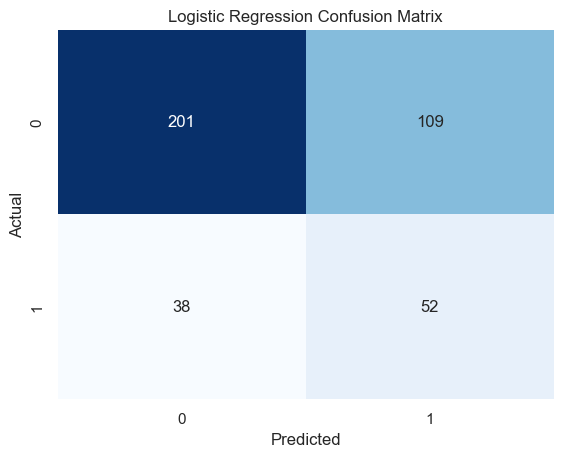

In [ ]:

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
lr_model = evaluate_model(lr_pipeline, "Logistic Regression")

### XGBoost Classifier

=== XGBoost Classifier ===
              precision    recall  f1-score   support

           0       0.79      0.88      0.84       310
           1       0.33      0.20      0.25        90

    accuracy                           0.73       400
   macro avg       0.56      0.54      0.54       400
weighted avg       0.69      0.73      0.70       400

ROC-AUC Score: 0.6121


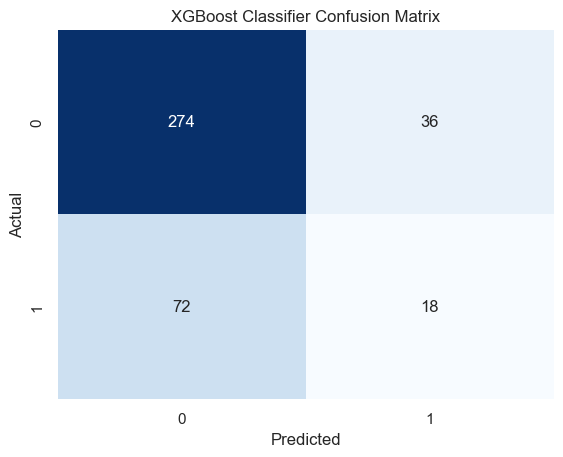

In [ ]:

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])
xgb_model = evaluate_model(xgb_pipeline, "XGBoost Classifier")

In [59]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Balanced)",
        "XGBoost"
    ],
    "Recall": [
        0.58,
        0.20
    ],
    "F1 Score": [
        0.41,
        0.25
    ],
    "ROC-AUC": [
        0.6689,
        0.6121
    ]
})

print(comparison)

                            Model  Recall  F1 Score  ROC-AUC
0  Logistic Regression (Balanced)    0.58      0.41   0.6689
1                         XGBoost    0.20      0.25   0.6121


### Feature Importance

In [60]:
feature_names = (
    lr_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    lr_pipeline.named_steps["classifier"]
    .coef_[0]
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df["Abs_Coefficient"] = (
    importance_df["Coefficient"].abs()
)

importance_df = (
    importance_df
    .sort_values(
        by="Abs_Coefficient",
        ascending=False
    )
)

print(importance_df.head(15))

                              Feature  Coefficient  Abs_Coefficient
0                 num__lead_time_days     0.663394         0.663394
83            cat__travel_month_March    -0.633388         0.633388
50                 cat__route_BLR-FRA     0.609694         0.609694
7             num__satisfaction_score    -0.609447         0.609447
62                 cat__route_DEL-SIN     0.579147         0.579147
65                 cat__route_HYD-LHR    -0.537646         0.537646
100   cat__fare_quintile_Q1\n(Lowest)     0.452937         0.452937
51                 cat__route_BLR-SFO    -0.436819         0.436819
107       cat__booking_month_name_Dec     0.401160         0.401160
71          cat__booking_day_Saturday    -0.391516         0.391516
57                 cat__route_COK-DOH     0.382118         0.382118
104  cat__fare_quintile_Q5\n(Highest)    -0.365204         0.365204
116       cat__booking_month_name_Sep    -0.359723         0.359723
35              cat__fare_basis_VOWRT     0.3462

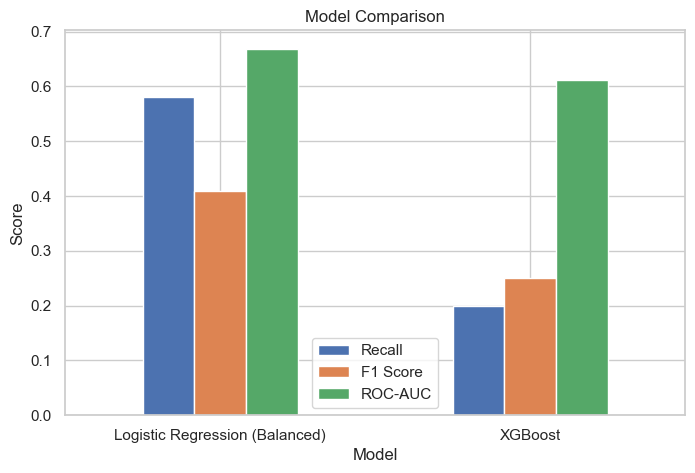

In [63]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [66]:
pip install pickle

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Logistic Regression (Balanced) = Best Model

### Analysis and Operationalisation Strategy

#### Model Performance & Feature Importance

Two classification models were evaluated: Logistic Regression and XGBoost. Contrary to expectations, the balanced Logistic Regression model outperformed XGBoost on this dataset, achieving a higher Recall (58%), F1-Score (0.41), and ROC-AUC score (0.6689).

Feature importance analysis revealed several key predictors of cancellation:

1. **Lead Time (`lead_time_days`)** – The strongest predictor. Bookings made significantly in advance showed a higher likelihood of cancellation, likely due to changing travel plans over time.

2. **Route Characteristics (`route_BLR-FRA`, `route_DEL-SIN`)** – Certain international routes exhibited higher cancellation tendencies, suggesting route-specific customer behaviour and demand patterns.

3. **Fare Characteristics (`fare_quintile`, `fare_per_passenger`)** – Lower-priced bookings were more likely to be cancelled, indicating higher price sensitivity among customers.

4. **Seasonality (`travel_month`, `booking_month`)** – Booking and travel periods influenced cancellation behaviour, highlighting seasonal travel trends.

#### Operationalisation at Clarity TTS

1. **Cancellation Risk Scoring**

   The model can be deployed as an API service within the booking workflow. Each booking receives a cancellation risk score, allowing operations teams to identify high-risk reservations before ticket issuance.

2. **Proactive Customer Outreach**

   Bookings with elevated cancellation risk can trigger automated reminders, payment confirmations, or customer engagement campaigns to reduce avoidable cancellations.

3. **Revenue and Capacity Forecasting**

   Predicted cancellations can be incorporated into forecasting systems, enabling Clarity and airline partners to estimate expected realised bookings more accurately and optimise inventory planning.

4. **Agent and Channel Monitoring**

   Cancellation risk patterns can be analysed across booking channels (B2B Agent, B2C Website, API Partner, Mobile App) to identify operational inefficiencies and improve booking quality.
